# Visual Analytics for Trustworthy GeoAI

## Uncertainty in Spatially Explicit Modeling 🖥️

Spatially explicit modeling builds geography into a model. Instead of treating
the whole world the same way, it models each place on its own terms. This is
powerful, but it adds new sources of uncertainty. We look at two of them, and —
because this is a course on **visual analytics** — we *draw* the uncertainty on
maps rather than only reporting numbers:

1. **Spatial inductive bias** — how we let a model use geography is a *choice*.
   We see what happens when we add coordinates to a model, and how an aspatial
   model (**Linear Regression**) and a spatial model (**GWR**) differ in
   confidence, measured with **GeoConformal Prediction**.
2. **Spatial transferability** — a model trained in one place often fails when
   moved to another. Using data for the whole US, we measure how performance
   changes between regions, and how the **way we split the map** changes the
   answer.

### Setup

The next cells install the packages (needed on Colab) and download the data and
the `geocp` package from the course repository.

In [1]:
import importlib, subprocess, sys
IMPORT_NAME = {"scikit-learn": "sklearn"}   # pip name -> import name
def _ensure(pkgs):
    missing = [p for p in pkgs
               if importlib.util.find_spec(IMPORT_NAME.get(p.split("==")[0], p.split("==")[0])) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
        print("installed:", ", ".join(missing))
    else:
        print("all packages already available")
_ensure(["geopandas", "mgwr", "libpysal", "esda", "scikit-learn", "xgboost"])

all packages already available


In [2]:
import os, urllib.request
REPO, BRANCH = "Vezarachan/TUM_Course_SVA_TrustGeoAI", "main"
DATA_FILES = ["data/seattle_sample_3k.csv", "data/king_county.gpkg", "data/US_Climate_ERA5_CLIMATE.csv"]
GEOCP_FILES = [f"geocp/{f}" for f in ["__init__.py","core.py","estimators.py","results.py","utils.py","weights.py"]]
for path in DATA_FILES + GEOCP_FILES:
    if not os.path.exists(path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        urllib.request.urlretrieve(f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{path}", path)
        print("downloaded", path)
    else:
        print("cached    ", path)

cached     data/seattle_sample_3k.csv
cached     data/king_county.gpkg
cached     data/US_Climate_ERA5_CLIMATE.csv
cached     geocp/__init__.py
cached     geocp/core.py
cached     geocp/estimators.py
cached     geocp/results.py
cached     geocp/utils.py
cached     geocp/weights.py


In [3]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from shapely.geometry import MultiPoint

# --- a clean, consistent visual style ---
INK, MUTED = "#1f2937", "#6b7280"
BLUE, RED, GREEN, AMBER = "#2c6fbb", "#c0392b", "#2e8b57", "#e08a3c"
mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "savefig.bbox": "tight",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size": 11, "axes.titlesize": 11, "axes.titlecolor": MUTED,
    "axes.labelcolor": INK, "text.color": INK,
    "axes.edgecolor": "#cfd3da", "axes.linewidth": 0.9,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5, "legend.frameon": False,
})
# perceptual colormaps used throughout
SEQ  = "magma_r"     # magnitude (interval width, |error|): dark = high
DIV  = "RdBu_r"      # signed residuals
PERF = "RdYlGn"      # performance / R^2
RNG = np.random.default_rng(42)

def finish_map(ax):
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)

def suptitle(fig, title):
    # constrained_layout reserves space for fig.suptitle automatically.
    fig.suptitle(title, fontsize=13.5, fontweight="bold", color=INK)

def cbar(fig, sc, ax, label):
    cb = fig.colorbar(sc, ax=ax, shrink=0.72, pad=0.02)
    cb.set_label(label, fontsize=9.5, color=INK); cb.ax.tick_params(labelsize=9, length=2)
    cb.outline.set_visible(False); return cb

print("style ready")

style ready


## Part 1 — Spatial inductive bias

How a model is allowed to use geography is an **inductive bias** — a built-in
assumption. We explore it with **Seattle house prices**: the (log) sale price of
3,000 homes, eight features, and each home's location.

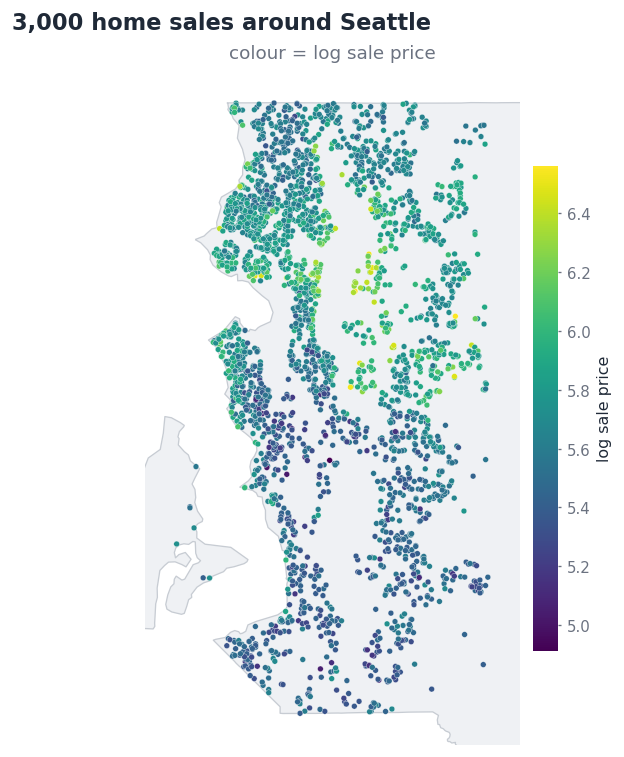

In [4]:
df = pd.read_csv("data/seattle_sample_3k.csv").drop(columns=["Unnamed: 0"])
FEATURES = ["bathrooms", "sqft_living", "sqft_lot", "grade", "condition", "waterfront", "view", "age"]
X = df[FEATURES].to_numpy(float)
y = df["log_price"].to_numpy(float)
coords = df[["UTM_X", "UTM_Y"]].to_numpy(float)     # UTM zone 10N, metres
xy_km = (coords - coords.mean(0)) / 1000.0           # centred km, for kernels & coord-features

# Seattle basemap: light county fill, zoomed to the homes.
county = gpd.read_file("data/king_county.gpkg", layer="county").to_crs(32610)
_PAD = 3000
X0, X1 = coords[:, 0].min()-_PAD, coords[:, 0].max()+_PAD
Y0, Y1 = coords[:, 1].min()-_PAD, coords[:, 1].max()+_PAD
def seattle_base(ax):
    county.plot(ax=ax, color="#eff1f4", edgecolor="white", linewidth=0.6, zorder=0)
    county.boundary.plot(ax=ax, color="#c7ccd3", linewidth=0.8, zorder=1)
    ax.set_xlim(X0, X1); ax.set_ylim(Y0, Y1); finish_map(ax)

fig, ax = plt.subplots(figsize=(6.6, 6.2), layout="constrained")
seattle_base(ax)
sc = ax.scatter(coords[:, 0], coords[:, 1], c=y, cmap="viridis", s=12,
                edgecolor="white", linewidth=0.2, zorder=2)
cbar(fig, sc, ax, "log sale price")
ax.set_title("colour = log sale price", pad=8)
suptitle(fig, "3,000 home sales around Seattle")
plt.show()

### 1.1 Does geography matter?

We fit a plain **Linear Regression** that uses the house features but **not**
location, and map its errors. If geography matters, the errors will cluster in
space — nearby homes wrong the same way. **Moran's I** measures that clustering.

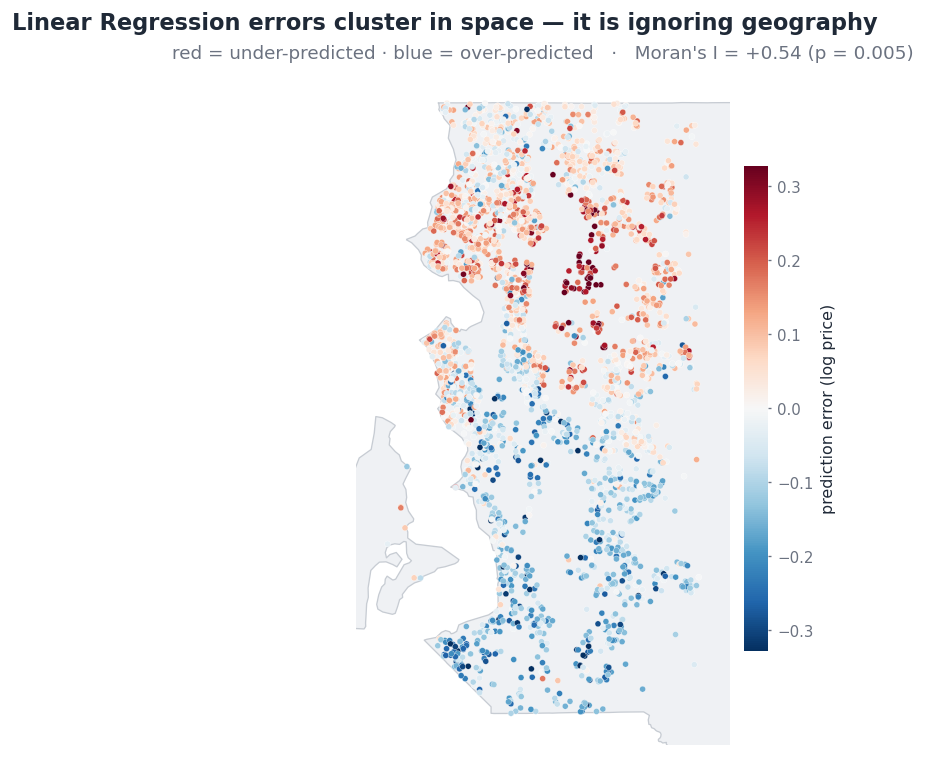

In [5]:
from sklearn.linear_model import LinearRegression
from libpysal.weights import KNN
from esda.moran import Moran

resid_lr = y - LinearRegression().fit(X, y).predict(X)
wq = KNN.from_array(coords, k=8); wq.transform = "r"
mi_lr = Moran(resid_lr, wq, permutations=199)

fig, ax = plt.subplots(figsize=(6.6, 6.2), layout="constrained")
seattle_base(ax)
v = np.percentile(np.abs(resid_lr), 98)
sc = ax.scatter(coords[:, 0], coords[:, 1], c=resid_lr, cmap=DIV, vmin=-v, vmax=v,
                s=13, edgecolor="white", linewidth=0.2, zorder=2)
cbar(fig, sc, ax, "prediction error (log price)")
ax.set_title(f"red = under-predicted · blue = over-predicted   ·   "
             f"Moran's I = {mi_lr.I:+.2f} (p = {mi_lr.p_sim:.3f})", pad=8)
suptitle(fig, "Linear Regression errors cluster in space — it is ignoring geography")
plt.show()

The errors are clearly not random — whole neighbourhoods are off in the same
direction. The model is missing *where*. The simplest fix is to **hand the model
the coordinates** and let it work out the geography itself.

### 1.2 Adding coordinates: a spatial inductive bias

We train a flexible model (**XGBoost**) two ways: once on the house features
alone, and once with the **coordinates added** to the inputs. Same model, same
data — the only difference is whether it can see *where* each house is.

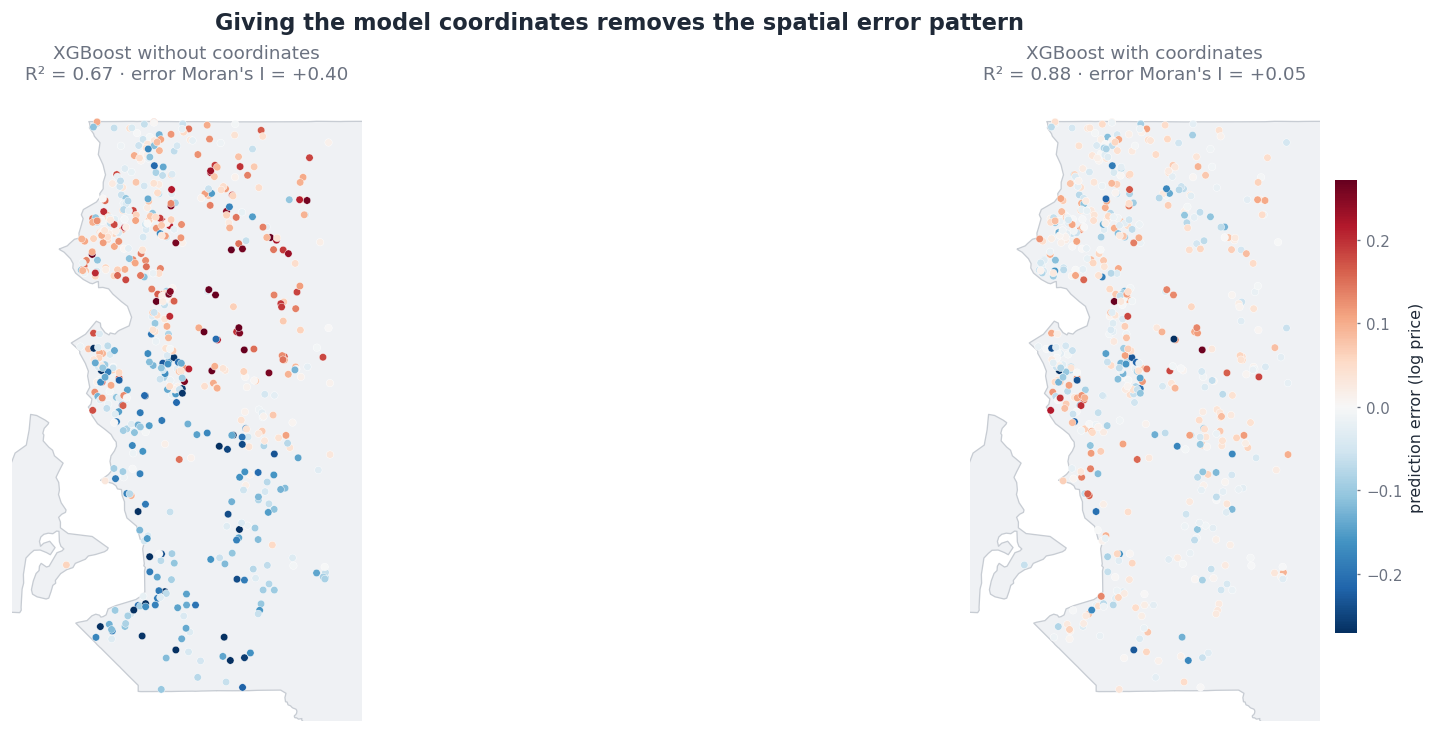

In [6]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

Xcoord = np.column_stack([X, xy_km])     # features + (x, y)
order = RNG.permutation(len(df)); tr, te = order[:int(.8*len(df))], order[int(.8*len(df)):]
def make_xgb():
    return XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                        subsample=0.9, colsample_bytree=0.9, random_state=0, n_jobs=-1)

m_no = make_xgb().fit(X[tr], y[tr])
m_yes = make_xgb().fit(Xcoord[tr], y[tr])
err_no = y[te] - m_no.predict(X[te])
err_yes = y[te] - m_yes.predict(Xcoord[te])

wt = KNN.from_array(coords[te], k=8); wt.transform = "r"
stats = {
    "no":  (r2_score(y[te], m_no.predict(X[te])),  Moran(err_no, wt, permutations=99).I),
    "yes": (r2_score(y[te], m_yes.predict(Xcoord[te])), Moran(err_yes, wt, permutations=99).I),
}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6), constrained_layout=True)
v = np.percentile(np.abs(np.r_[err_no, err_yes]), 98)
for ax, e, key, name in [(axes[0], err_no, "no", "without coordinates"),
                         (axes[1], err_yes, "yes", "with coordinates")]:
    seattle_base(ax)
    sc = ax.scatter(coords[te, 0], coords[te, 1], c=e, cmap=DIV, vmin=-v, vmax=v,
                    s=20, edgecolor="white", linewidth=0.25, zorder=2)
    r2, miI = stats[key]
    ax.set_title(f"XGBoost {name}\nR² = {r2:.2f} · error Moran's I = {miI:+.2f}", pad=8)
cbar(fig, sc, axes[1], "prediction error (log price)")
suptitle(fig, "Giving the model coordinates removes the spatial error pattern")
plt.show()

Without coordinates, XGBoost's errors still cluster (Moran's I stays high) — it
is flexible but blind to location. **Add the coordinates** and the error pattern
nearly vanishes (Moran's I drops toward 0) while accuracy jumps. The
coordinates-as-features are a simple but real **spatial inductive bias**: we told
the model that location carries information, and it used it.

### 1.3 How confident is each model? GeoConformal Prediction

Accuracy is not the whole story — we want to know *how confident* a model is, and
*where*. **GeoConformal Prediction (GeoCP)** turns any model into prediction
intervals: it weights the model's calibration errors by spatial distance to each
test point, so the interval width is the **local uncertainty**. We compare an
aspatial model (**Linear Regression**) with a dedicated spatial model (**GWR**).

In [7]:
from mgwr.gwr import GWR
from geocp import GeoConformalPrediction
from geocp.weights import spatial_kernel_weights

# 60/20/20: fit models on 'fit', calibrate GeoCP on 'cal', evaluate on 'test'.
n = len(df); o2 = RNG.permutation(n)
fit_i, cal_i, test_i = o2[:int(.6*n)], o2[int(.6*n):int(.8*n)], o2[int(.8*n):]
sub = np.concatenate([cal_i, test_i])

# GWR (a spatial model): fit on 'fit', predict at cal+test (mgwr needs n_pred < n_fit).
GF = ["sqft_living", "grade", "age", "condition", "bathrooms"]
Xg = df[GF].to_numpy(float); mu, sd = Xg[fit_i].mean(0), Xg[fit_i].std(0)
Xs = (Xg - mu) / sd; ym = y[fit_i].mean()
gwr = GWR(coords[fit_i], (y[fit_i]-ym).reshape(-1, 1), Xs[fit_i], 200, fixed=False, kernel="bisquare")

pred_lr = np.full(n, np.nan);  pred_lr[sub]  = LinearRegression().fit(X[fit_i], y[fit_i]).predict(X[sub])
pred_gwr = np.full(n, np.nan); pred_gwr[sub] = gwr.predict(coords[sub], Xs[sub]).predictions.flatten() + ym

def predf(p): return lambda ii: p[np.asarray(ii).astype(int).ravel()]
def geocp_width(p, bw_km=6.0):
    cp = GeoConformalPrediction(predf(p), cal_i.reshape(-1, 1), y[cal_i],
                                spatial_kernel_weights(xy_km[cal_i], bandwidth=bw_km), miscoverage_level=0.10)
    r = cp.conformalize(test_i.reshape(-1, 1), y[test_i], coord_test=xy_km[test_i])
    return 2*r.uncertainty, r.coverage

w_lr, cov_lr = geocp_width(pred_lr)
w_gwr, cov_gwr = geocp_width(pred_gwr)
fin = np.isfinite(w_lr) & np.isfinite(w_gwr)
ct, w_lr, w_gwr = coords[test_i][fin], w_lr[fin], w_gwr[fin]
print(f"Linear Regression : coverage {cov_lr:.3f} | mean interval width {w_lr.mean():.3f}")
print(f"GWR               : coverage {cov_gwr:.3f} | mean interval width {w_gwr.mean():.3f}")

Linear Regression : coverage 0.895 | mean interval width 0.447
GWR               : coverage 0.908 | mean interval width 0.295


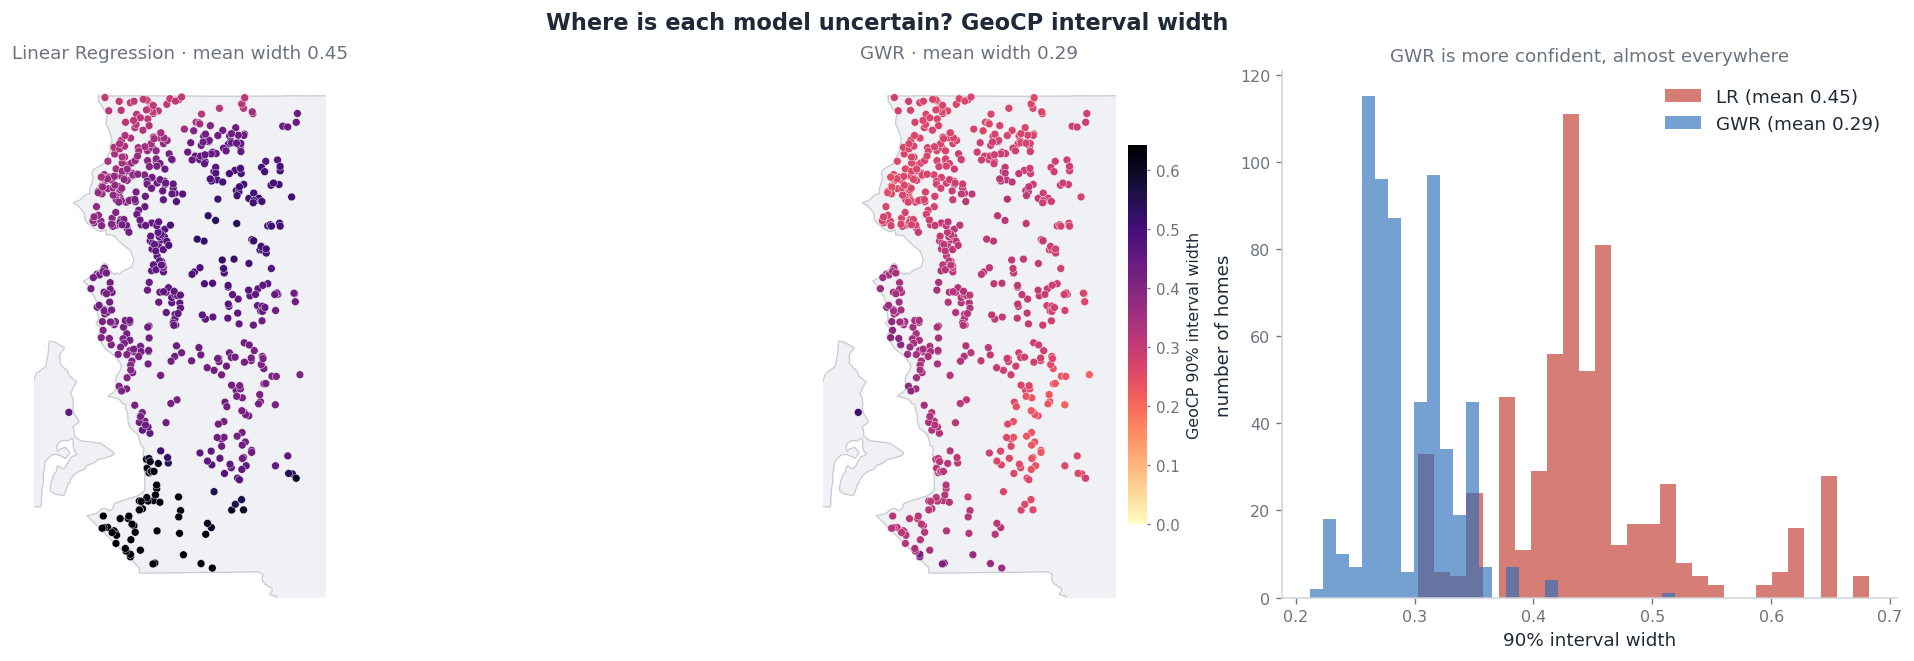

In [8]:
wmax = np.percentile(np.r_[w_lr, w_gwr], 98)
fig, axes = plt.subplots(1, 3, figsize=(17, 5.4), constrained_layout=True)
for ax, wdt, name in [(axes[0], w_lr, "Linear Regression"), (axes[1], w_gwr, "GWR")]:
    seattle_base(ax)
    sc = ax.scatter(ct[:, 0], ct[:, 1], c=wdt, cmap=SEQ, vmin=0, vmax=wmax,
                    s=22, edgecolor="white", linewidth=0.25, zorder=2)
    ax.set_title(f"{name} · mean width {wdt.mean():.2f}", pad=8)
cbar(fig, sc, axes[1], "GeoCP 90% interval width")
axes[2].hist(w_lr, bins=28, color=RED, alpha=0.65, label=f"LR (mean {w_lr.mean():.2f})")
axes[2].hist(w_gwr, bins=28, color=BLUE, alpha=0.65, label=f"GWR (mean {w_gwr.mean():.2f})")
axes[2].set_xlabel("90% interval width"); axes[2].set_ylabel("number of homes")
axes[2].legend(); axes[2].set_title("GWR is more confident, almost everywhere", color=MUTED)
suptitle(fig, "Where is each model uncertain? GeoCP interval width")
plt.show()

Both models reach the promised ~90% coverage, so both are *honest*. But the
spatial model is **more confident**: GWR's intervals are visibly narrower. We can
also ask whether one model's uncertainty is more *uneven* (coefficient of
variation, CV) or more *spatially patterned* (Moran's I of the widths):

In [9]:
def width_stats(wdt, xyc):
    knn = KNN.from_array(xyc, k=8); knn.transform = "r"
    return wdt.std()/wdt.mean(), Moran(wdt, knn, permutations=99).I

cv_lr, mw_lr = width_stats(w_lr, ct)
cv_gwr, mw_gwr = width_stats(w_gwr, ct)
print(f"{'':18}{'mean width':>12}{'CV (uneven)':>14}{'Moran I (pattern)':>20}")
print(f"{'Linear Regression':18}{w_lr.mean():>12.3f}{cv_lr:>14.3f}{mw_lr:>20.3f}")
print(f"{'GWR':18}{w_gwr.mean():>12.3f}{cv_gwr:>14.3f}{mw_gwr:>20.3f}")

                    mean width   CV (uneven)   Moran I (pattern)
Linear Regression        0.447         0.177               0.955
GWR                      0.295         0.120               0.870


GWR's uncertainty is **not** more uneven — its CV is about the same or lower, and
its widths are uniformly smaller. **Both** width maps are strongly spatially
clustered (Moran's I ≈ 0.9), because GeoCP builds each interval from nearby
calibration errors, so neighbouring homes share information by construction. The
inductive bias mainly shifts the **overall level** of uncertainty, not its
spatial unevenness.

> ❓**Question:** Adding coordinates (1.2) and using GWR (1.3) are two different
> ways to give a model geography. From the maps, where does each one help most?
> If you could only report one uncertainty map to a decision-maker, which model's
> would you choose, and why?

[Your Answer]

## Part 2 — Spatial transferability

A model trained in one place is often used in another. Does it still work? We use
a US climate dataset (`US_Climate_ERA5_CLIMATE.csv`): a target `Y` and nine
predictors at thousands of locations, each labelled with its US **climate
region**. We measure how performance changes when a model is moved between
regions — and how the **way we partition the map** changes that measurement.

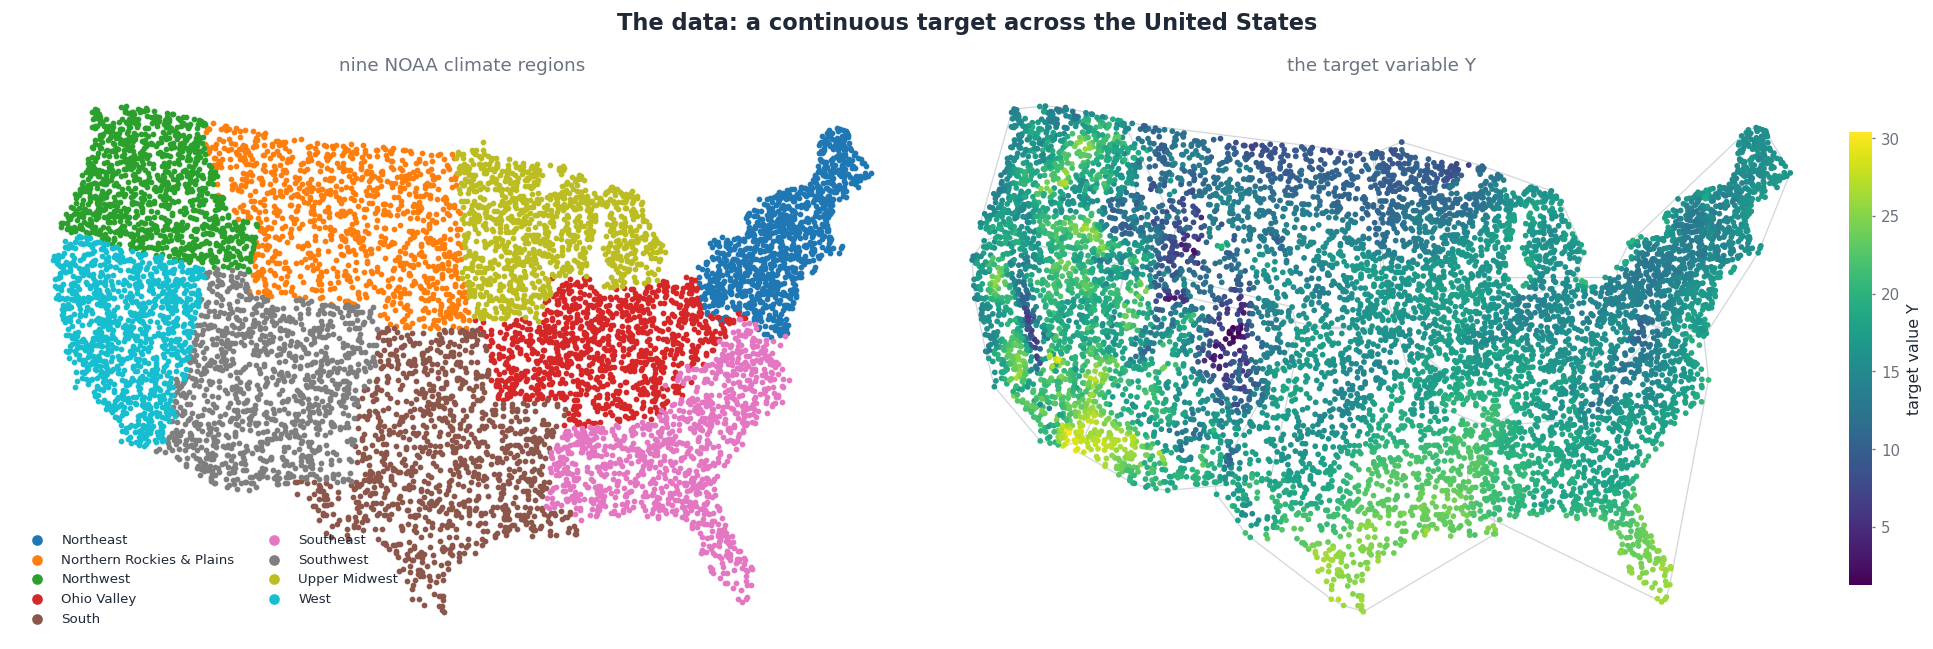

In [10]:
clim = pd.read_csv("data/US_Climate_ERA5_CLIMATE.csv").groupby("region").sample(n=1000, random_state=1).reset_index(drop=True)
CF = [c for c in clim.columns if c.startswith("X")]
Xc = clim[CF].to_numpy(float); yc = clim["Y"].to_numpy(float)
region = clim["region"].to_numpy()
REGIONS = sorted(clim["region"].unique())
lonlat = clim[["lon", "lat"]].to_numpy(float)

gc = gpd.GeoDataFrame(clim, geometry=gpd.points_from_xy(clim.lon, clim.lat), crs=4326).to_crs(5070)
cxy = np.c_[gc.geometry.x.values, gc.geometry.y.values] / 1000.0
REG_CMAP = plt.get_cmap("tab10", len(REGIONS))
REG_COL = {r: REG_CMAP(k) for k, r in enumerate(REGIONS)}

# Faint convex-hull outline per region, derived from the data (a free 'basemap').
HULLS = {r: MultiPoint([tuple(p) for p in cxy[region == r]]).convex_hull for r in REGIONS}
def us_hulls(ax, color="#d4d8de", lw=0.8, fill=False):
    for r in REGIONS:
        xs, ys = HULLS[r].exterior.xy
        ax.plot(xs, ys, color=color, lw=lw, zorder=0)

def us_finish(ax):
    finish_map(ax)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.6), constrained_layout=True)
for k, r in enumerate(REGIONS):
    m = region == r
    axes[0].scatter(cxy[m, 0], cxy[m, 1], s=6, color=REG_COL[r], label=r)
axes[0].legend(markerscale=2.2, fontsize=8, loc="lower left", ncol=2); us_finish(axes[0])
axes[0].set_title("nine NOAA climate regions", pad=6)
us_hulls(axes[1])
sc = axes[1].scatter(cxy[:, 0], cxy[:, 1], c=yc, cmap="viridis", s=6); us_finish(axes[1])
cbar(fig, sc, axes[1], "target value Y"); axes[1].set_title("the target variable Y", pad=6)
suptitle(fig, "The data: a continuous target across the United States")
plt.show()

### 2.1 Train here, predict there: the transfer matrix

We train one model on **each** region and test it on **every** region. The result
is a matrix: row = trained-on, column = tested-on, colour = R². The **diagonal**
is the easy case (same region); everything **off the diagonal** is a transfer.

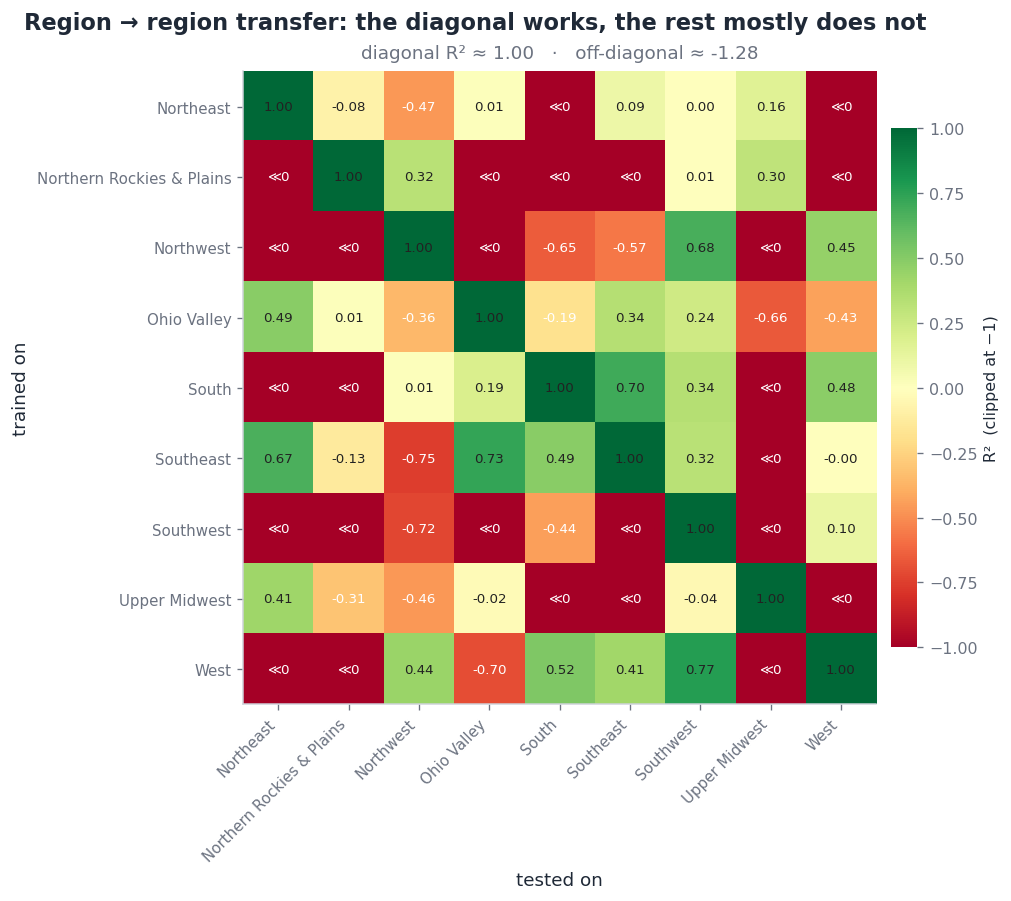

In [11]:
from sklearn.metrics import r2_score

def make_model():
    return XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.07,
                        subsample=0.9, random_state=0, n_jobs=-1)
models = {r: make_model().fit(Xc[region == r], yc[region == r]) for r in REGIONS}
R2 = np.array([[r2_score(yc[region == te], models[tr].predict(Xc[region == te]))
                for te in REGIONS] for tr in REGIONS])

fig, ax = plt.subplots(figsize=(8.8, 7.4), layout="constrained")
im = ax.imshow(R2, cmap=PERF, vmin=-1, vmax=1)
ax.set_xticks(range(len(REGIONS))); ax.set_yticks(range(len(REGIONS)))
ax.set_xticklabels(REGIONS, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(REGIONS, fontsize=9)
ax.set_xlabel("tested on", color=INK); ax.set_ylabel("trained on", color=INK)
for i in range(len(REGIONS)):
    for j in range(len(REGIONS)):
        v = R2[i, j]
        ax.text(j, i, f"{v:.2f}" if v > -1 else "≪0", ha="center", va="center",
                fontsize=8, color="#222" if v > -0.15 else "white")
cb = fig.colorbar(im, ax=ax, shrink=0.82, pad=0.02); cb.set_label("R²  (clipped at −1)", fontsize=9.5)
cb.outline.set_visible(False)
ax.set_title(f"diagonal R² ≈ {np.mean(np.diag(R2)):.2f}   ·   "
             f"off-diagonal ≈ {(R2.sum()-np.trace(R2))/(R2.size-len(REGIONS)):.2f}", pad=8)
suptitle(fig, "Region → region transfer: the diagonal works, the rest mostly does not")
plt.show()

The diagonal is green (R² ≈ 0.99): within a region, prediction is excellent.
Almost everything off the diagonal is yellow-to-red — often **R² below 0**,
meaning the transferred model is *worse than predicting the average*. A model
that is perfect at home can be useless one region over. We can see *where* it
breaks by training on one region and mapping the error:

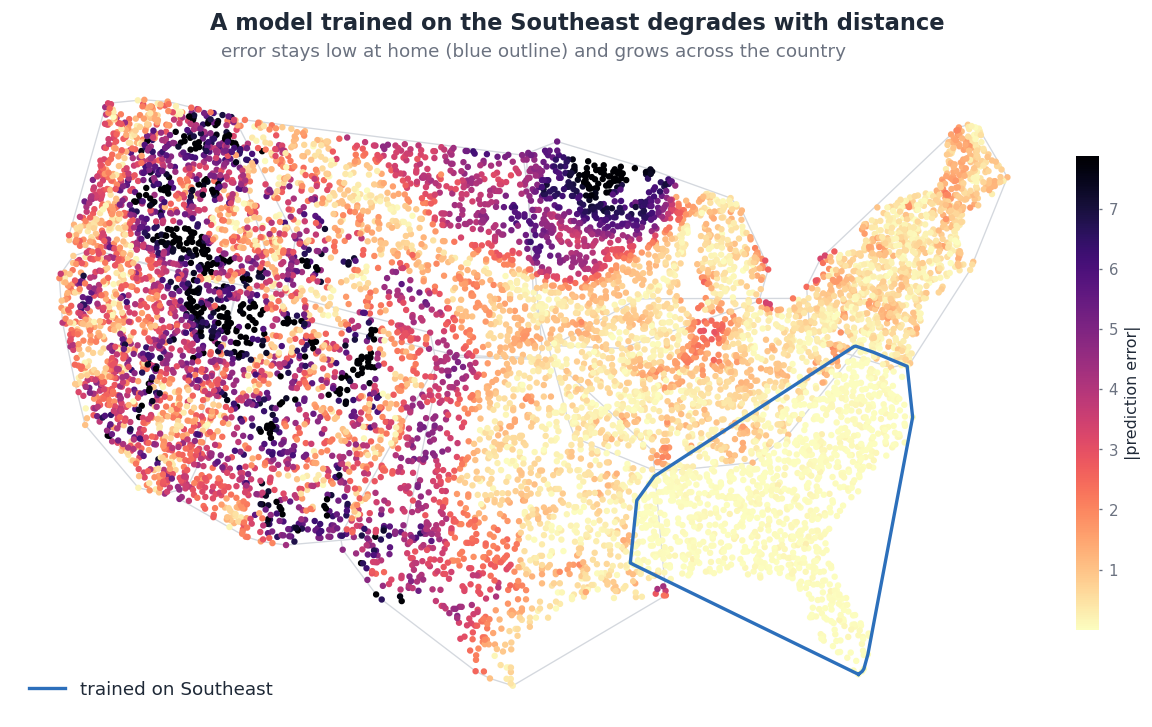

In [12]:
SRC = "Southeast"
err = np.abs(yc - models[SRC].predict(Xc))
fig, ax = plt.subplots(figsize=(9.5, 6), layout="constrained")
us_hulls(ax)
sc = ax.scatter(cxy[:, 0], cxy[:, 1], c=err, cmap=SEQ, s=8, vmax=np.percentile(err, 97))
m = region == SRC
xs, ys = HULLS[SRC].exterior.xy
ax.plot(xs, ys, color=BLUE, lw=2, zorder=3, label=f"trained on {SRC}")
ax.legend(loc="lower left"); us_finish(ax)
cbar(fig, sc, ax, "|prediction error|")
ax.set_title("error stays low at home (blue outline) and grows across the country", pad=8)
suptitle(fig, f"A model trained on the {SRC} degrades with distance")
plt.show()

### 2.2 The way you split the map changes the answer

How well a model "generalises" depends entirely on **how we split the data for
testing**. We estimate performance four ways and compare:

* **Random K-fold** — test points scattered among training points (the usual ML
  default).
* **Spatial blocks** — a 3×3 grid; hold out one block at a time.
* **Climate region** — hold out one whole region at a time.
* **Spatial clusters** — k-means on coordinates; hold out one cluster at a time.

All four use the *same data and model*. Only the partition changes.

In [13]:
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans

def cv_mean(folds):
    s = []
    for tr_idx, te_idx in folds:
        if len(tr_idx) and len(te_idx):
            s.append(r2_score(yc[te_idx], make_model().fit(Xc[tr_idx], yc[tr_idx]).predict(Xc[te_idx])))
    return np.array(s)

rand = list(KFold(5, shuffle=True, random_state=0).split(Xc))
randlab = np.zeros(len(Xc), int)
for fid, (_, te_idx) in enumerate(rand): randlab[te_idx] = fid   # per-point fold id
qx, qy = np.quantile(lonlat[:, 0], [1/3, 2/3]), np.quantile(lonlat[:, 1], [1/3, 2/3])
block = np.digitize(lonlat[:, 0], qx) * 3 + np.digitize(lonlat[:, 1], qy)
blocks = [(np.where(block != b)[0], np.where(block == b)[0]) for b in np.unique(block)]
regs = [(np.where(region != r)[0], np.where(region == r)[0]) for r in REGIONS]
km = KMeans(9, n_init=10, random_state=0).fit_predict(lonlat)
clus = [(np.where(km != c)[0], np.where(km == c)[0]) for c in np.unique(km)]

SCHEMES = [("Random\nK-fold", rand, randlab), ("Spatial\n3×3 blocks", blocks, block),
           ("Climate\nregion", regs, None), ("Spatial\nclusters", clus, km)]
scores = {name: cv_mean(folds) for name, folds, _ in SCHEMES}
for name, s in scores.items():
    print(f"{name.replace(chr(10),' '):20s} mean R² = {s.mean():+.3f}  (folds: {', '.join(f'{x:.2f}' for x in s)})")

Random K-fold        mean R² = +0.938  (folds: 0.94, 0.94, 0.94, 0.94, 0.94)
Spatial 3×3 blocks   mean R² = +0.551  (folds: 0.83, 0.71, 0.59, 0.84, 0.92, -1.12, 0.88, 0.69, 0.62)
Climate region       mean R² = +0.524  (folds: 0.36, -0.37, 0.47, 0.76, 0.88, 0.90, 0.85, 0.13, 0.74)
Spatial clusters     mean R² = +0.601  (folds: 0.92, 0.78, 0.50, 0.56, 0.79, 0.82, 0.37, 0.44, 0.23)


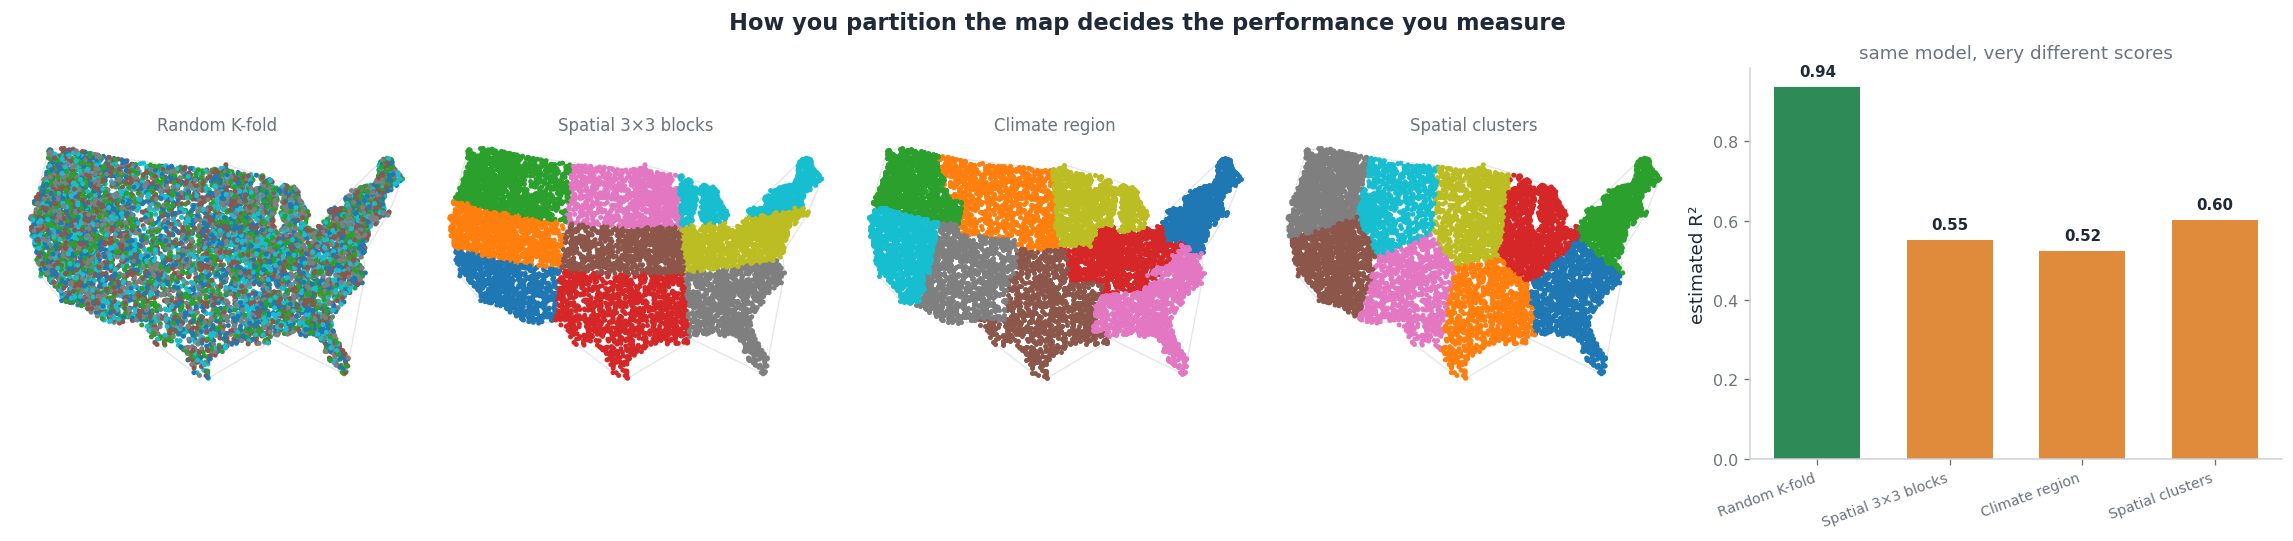

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(19, 4.4), layout="constrained", gridspec_kw={"width_ratios":[1,1,1,1,1.3]})
# four partition maps
for ax, (name, folds, lab) in zip(axes[:4], SCHEMES):
    us_hulls(ax, color="#e3e6ea")
    if lab is None:   # climate region
        for k, r in enumerate(REGIONS):
            ax.scatter(cxy[region == r, 0], cxy[region == r, 1], s=4, color=REG_CMAP(k))
    else:
        ax.scatter(cxy[:, 0], cxy[:, 1], s=4, c=lab, cmap="tab10")
    us_finish(ax); ax.set_title(name.replace("\n", " "), pad=4, fontsize=10)
# summary bar
names = [n for n, _, _ in SCHEMES]; means = [scores[n].mean() for n in names]
colors = [GREEN if m > 0.8 else (AMBER if m > 0 else RED) for m in means]
b = axes[4].bar(range(4), means, color=colors, width=0.65)
axes[4].axhline(0, color=MUTED, lw=0.8)
axes[4].set_xticks(range(4)); axes[4].set_xticklabels([n.replace("\n"," ") for n in names], rotation=20, ha="right", fontsize=8.5)
axes[4].set_ylabel("estimated R²"); axes[4].set_title("same model, very different scores", color=MUTED)
for r, m in zip(b, means):
    axes[4].text(r.get_x()+r.get_width()/2, m+0.02, f"{m:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
suptitle(fig, "How you partition the map decides the performance you measure")
plt.show()

The **random split is wildly optimistic** (R² ≈ 0.94): its test points sit right
next to training points, so the model barely has to generalise. Every
**spatially aware** split — blocks, climate regions, clusters — tells the honest
story (R² ≈ 0.5–0.6, with some folds below zero), because the test locations are
genuinely *elsewhere*. For spatial data, a random train/test split measures the
wrong thing. The partition is part of the experiment.

> ❓**Question:** A report claims a GeoAI model "achieves R² = 0.94" using random
> cross-validation. Based on 2.1 and 2.2, why might that number be misleading for
> deployment in a new region, and which evaluation would you ask for instead?

[Your Answer]

## Wrap-up

Spatial modeling does not remove uncertainty — it moves it into the assumptions
we make and the gap between where we train and where we predict. Visual analytics
is how we *find* it:

| What we drew | What it revealed |
|---|---|
| **LR error map + Moran's I** (1.1) | an aspatial model ignores geography; its errors cluster |
| **XGBoost ± coordinates** (1.2) | adding coordinates is a spatial inductive bias — it removes the spatial error pattern |
| **GeoCP width maps: LR vs GWR** (1.3) | a spatial model is more confident, and we can see where |
| **Region → region transfer matrix** (2.1) | a model transferred to another region usually breaks (R² < 0) |
| **Partition-scheme comparison** (2.2) | the way you split the map decides the score you measure |

**Takeaways**

1. How a model uses geography — coordinates as features, a spatial model, a
   kernel — is a *choice* that changes both accuracy and confidence.
2. A model that looks perfect at home can fail in a new region; always evaluate
   transfer with a **spatial** split, never a random one.
3. The evaluation design (the partition) is part of the result — report it.